# Fraud Detection with Multiple Classifiers

This notebook uses a simple 100-row fraud sample to explain preprocessing, EDA, model training, model comparison, and the MLOps lifecycle.

## 1. Import Libraries

In [1]:
from datetime import datetime
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 2. Load and Prepare Data

In [2]:
DATA_FILE = "creditcard.csv"
TARGET_COLUMN = "Class"
SAMPLE_SIZE = 100
RANDOM_STATE = 42

data = pd.read_csv(DATA_FILE)

fraud = data[data[TARGET_COLUMN] == 1].sample(SAMPLE_SIZE // 2, random_state=RANDOM_STATE)
non_fraud = data[data[TARGET_COLUMN] == 0].sample(SAMPLE_SIZE // 2, random_state=RANDOM_STATE)

data = pd.concat([fraud, non_fraud], ignore_index=True)
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
data.columns = [column.lower() for column in data.columns]
data = data.drop_duplicates().reset_index(drop=True)

print("\nData shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head().to_string(index=False))
print("\nClass count:")
print(data["class"].value_counts().to_string())
print("\nMissing values:")
print(data.isnull().sum().to_string())


Data shape: (100, 30)

First 5 rows:
        v1        v2        v3        v4        v5        v6         v7         v8        v9       v10       v11       v12       v13       v14       v15       v16       v17       v18       v19       v20       v21       v22       v23       v24       v25       v26       v27       v28  amount  class
  1.940459 -0.856195 -1.350666 -0.769440  1.428500  4.021573  -1.521769   1.136225  1.220112 -0.007625 -0.101835  0.389297  0.089459 -0.136574  1.181271  0.588169 -0.722829 -0.102558 -0.439729 -0.074945  0.038397  0.128856  0.349834  0.730631 -0.563444  0.500995  0.005508 -0.042418   19.50      0
 -0.060302  1.065093 -0.987421 -0.029567  0.176376 -1.348539   0.775644   0.134843 -0.149734 -1.238598 -0.841133 -0.586472 -0.779620 -0.436671  0.747871  0.266437  0.703234  0.916719 -0.189967 -0.169706  0.355576  0.907570 -0.018454 -0.126269 -0.339923 -0.150285 -0.023634  0.042330   57.00      0
  0.323702 -2.452208 -0.884309 -0.010207  0.575348  4.367675  -0.837

## 3. EDA Charts

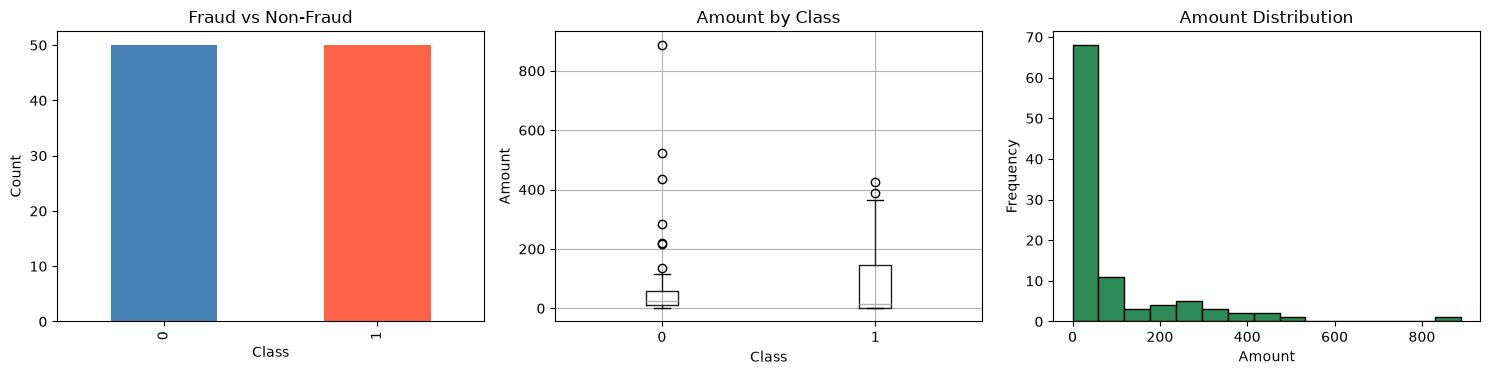

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data["class"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Fraud vs Non-Fraud")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

data.boxplot(column="amount", by="class", ax=axes[1])
axes[1].set_title("Amount by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Amount")

data["amount"].plot(kind="hist", bins=15, ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Amount Distribution")
axes[2].set_xlabel("Amount")

plt.suptitle("")
plt.tight_layout()
plt.show()

## 4. Train Multiple Classification Models

In [4]:
X = data.drop("class", axis=1)
y = data["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}

stacking_model = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ("svc", SVC(probability=True, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
models["Stacking Classifier"] = stacking_model

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    predictions = model.predict(X_test_scaled)
    probabilities = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_test, probabilities)

    results.append(
        {
            "Model": name,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),
        }
    )

    print(f"\n{name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

results = pd.DataFrame(results).sort_values(by=["F1 Score", "ROC AUC"], ascending=False).reset_index(drop=True)
best_model_name = results.iloc[0]["Model"]
best_model_object = trained_models[best_model_name]
results


Logistic Regression
Accuracy : 0.7500
Precision: 1.0000
Recall   : 0.5000
F1 Score : 0.6667
ROC AUC  : 0.9400

SVC
Accuracy : 0.8500
Precision: 1.0000
Recall   : 0.7000
F1 Score : 0.8235
ROC AUC  : 0.9200

Random Forest
Accuracy : 0.8500
Precision: 1.0000
Recall   : 0.7000
F1 Score : 0.8235
ROC AUC  : 0.9400



Gradient Boosting
Accuracy : 0.9000
Precision: 1.0000
Recall   : 0.8000
F1 Score : 0.8889
ROC AUC  : 0.8800

XGBoost
Accuracy : 0.9000
Precision: 1.0000
Recall   : 0.8000
F1 Score : 0.8889
ROC AUC  : 0.9200



Stacking Classifier
Accuracy : 0.8500
Precision: 1.0000
Recall   : 0.7000
F1 Score : 0.8235
ROC AUC  : 0.9400


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,0.90,1.0,0.8,0.8889,0.92
1,Gradient Boosting,0.90,1.0,0.8,0.8889,0.88
2,Random Forest,0.85,1.0,0.7,0.8235,0.94
3,Stacking Classifier,0.85,1.0,0.7,0.8235,0.94
4,SVC,0.85,1.0,0.7,0.8235,0.92
5,Logistic Regression,0.75,1.0,0.5,0.6667,0.94


## 5. Model Packaging

This is the first real MLOps step after training.

What we add here:
- save the best model
- save the scaler used during preprocessing
- save metadata like metrics, features, and training date

Why this matters:
- without packaging, the model only exists inside the notebook session
- with packaging, the model becomes a reusable artifact for deployment

In [5]:
packaged_model_dir = Path("packaged_model")
packaged_model_dir.mkdir(exist_ok=True)

model_path = packaged_model_dir / "best_model.joblib"
scaler_path = packaged_model_dir / "scaler.joblib"
metadata_path = packaged_model_dir / "model_metadata.json"

joblib.dump(best_model_object, model_path)
joblib.dump(scaler, scaler_path)

best_model_metrics = results.iloc[0].to_dict()

metadata = {
    "model_name": best_model_name,
    "saved_at": datetime.now().isoformat(),
    "sample_size": SAMPLE_SIZE,
    "target_column": "class",
    "feature_columns": X.columns.tolist(),
    "metrics": best_model_metrics,
    "model_file": str(model_path),
    "scaler_file": str(scaler_path)
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Best model packaged successfully.")
print("Saved files:")
print(model_path)
print(scaler_path)
print(metadata_path)
print("\nSaved metadata preview:")
print(json.dumps(metadata, indent=2)[:1200])

Best model packaged successfully.
Saved files:
packaged_model\best_model.joblib
packaged_model\scaler.joblib
packaged_model\model_metadata.json

Saved metadata preview:
{
  "model_name": "XGBoost",
  "saved_at": "2026-06-20T09:27:28.189426",
  "sample_size": 100,
  "target_column": "class",
  "feature_columns": [
    "v1",
    "v2",
    "v3",
    "v4",
    "v5",
    "v6",
    "v7",
    "v8",
    "v9",
    "v10",
    "v11",
    "v12",
    "v13",
    "v14",
    "v15",
    "v16",
    "v17",
    "v18",
    "v19",
    "v20",
    "v21",
    "v22",
    "v23",
    "v24",
    "v25",
    "v26",
    "v27",
    "v28",
    "amount"
  ],
  "metrics": {
    "Model": "XGBoost",
    "Accuracy": 0.9,
    "Precision": 1.0,
    "Recall": 0.8,
    "F1 Score": 0.8889,
    "ROC AUC": 0.92
  },
  "model_file": "packaged_model\\best_model.joblib",
  "scaler_file": "packaged_model\\scaler.joblib"
}


## 6. Experiment Tracking and Model Registry with MLflow

Now we move from simple file saving to an actual open-source MLOps tool.

What changes here:
- every training run is logged
- metrics and parameters are stored in one place
- the packaged model is registered with a version

Why this matters:
- file saving is useful, but it does not manage experiments well
- MLflow helps us answer: which run was best, what changed, and which model version should be used

In [6]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("fraud-detection-demo")

registered_model_name = "fraud-classifier-demo"

with mlflow.start_run(run_name=best_model_name):
    mlflow.log_param("sample_size", SAMPLE_SIZE)
    mlflow.log_param("best_model_name", best_model_name)
    mlflow.log_param("target_column", "class")

    mlflow.log_metric("accuracy", float(results.iloc[0]["Accuracy"]))
    mlflow.log_metric("precision", float(results.iloc[0]["Precision"]))
    mlflow.log_metric("recall", float(results.iloc[0]["Recall"]))
    mlflow.log_metric("f1_score", float(results.iloc[0]["F1 Score"]))
    mlflow.log_metric("roc_auc", float(results.iloc[0]["ROC AUC"]))

    mlflow.log_artifact(str(model_path))
    mlflow.log_artifact(str(scaler_path))
    mlflow.log_artifact(str(metadata_path))

    model_info = mlflow.sklearn.log_model(
        sk_model=best_model_object,
        name="model",
        serialization_format="cloudpickle",
        registered_model_name=registered_model_name
    )

print("MLflow logging complete.")
print("Registered model name:", registered_model_name)
print("Logged model URI:", model_info.model_uri)
print("\nYou can inspect runs later using the MLflow UI.")

2026/06/20 09:27:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully registered model 'fraud-classifier-demo'.


MLflow logging complete.
Registered model name: fraud-classifier-demo
Logged model URI: models:/m-c6a9520b5bac495b99fb627dfe280355

You can inspect runs later using the MLflow UI.


Created version '1' of model 'fraud-classifier-demo'.


## 7. MLOps Lifecycle Summary

In [7]:
best_model = results.iloc[0]

print("\nMLOps lifecycle using this demo:")
print("1. Collect data")
print("2. Validate and clean data")
print("3. Explore data with EDA charts")
print("4. Preprocess features")
print("5. Train multiple models including XGBoost")
print(f"6. Select best model: {best_model['Model']}")
print("7. Package the model, scaler, and metadata")
print("8. Track the experiment and register the model in MLflow")
print("9. Deploy through a serving layer like BentoML")
print("10. Monitor predictions and drift")
print("11. Retrain when data changes")


MLOps lifecycle using this demo:
1. Collect data
2. Validate and clean data
3. Explore data with EDA charts
4. Preprocess features
5. Train multiple models including XGBoost
6. Select best model: XGBoost
7. Package the model, scaler, and metadata
8. Track the experiment and register the model in MLflow
9. Deploy through a serving layer like BentoML
10. Monitor predictions and drift
11. Retrain when data changes
